In [1]:
import sys
import argparse
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import numpy as np
import pandas as pd

import csv
import gzip

import scipy.io
import numpy as np 

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.pyplot import rc_context
import anndata
import torch

# --- MATPLOTLIB SETTINGS ---
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
rc_params = {
    "font.family": "sans-serif", # "text.usetex": True,
    "font.serif" : ['Arial'], # "font.size" : 6,
    "font.weight" : "normal",
    'xtick.labelsize' : 5,
    'ytick.labelsize' : 5,
    'legend.fontsize' : 5,
    'axes.labelsize' : 6,
    'axes.linewidth': 0.8,
    'lines.linewidth' : 1,
    'axes.titlesize' : 7, # figure.titlesize,
    'legend.title_fontsize' : 5
}
matplotlib.rcParams.update(rc_params)
margins = {  #     vvv margin in inches
    "left"   :     0.2,
    'right' : 1.0,
    'bottom' : 0.15
}

import helper_functions



/Users/mingyaolab/opt/anaconda3/envs/misalignment/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# --- INIT ---


# which data to use
head_folder = "/".join(os.getcwd().split("/")[:3])
data_head_folder = '%s/Dropbox/aorta_circadian_data/datasets/joint' % head_folder
hvg_to_use = 'prior_knowledge_guided' # 'transformed_X_outlier_variance'
cluster_resolution = 0.05
subcluster_resolution = 0.20

# get corresponding paths
adata_path = '%s/adata_qc_filtered.h5ad' % data_head_folder
hvg_folder = '%s/data_annotations/hvg/%s' % (data_head_folder,hvg_to_use)
scvi_res_folder = '%s/scvi_res' % hvg_folder
scvi_mean_embedding_df_path = '%s/scvi_mean_embedding.tsv' % scvi_res_folder
umap_path_out = '%s/scvi_mean_umap_embedding.tsv' % scvi_res_folder
clustering_folder = '%s/clustering/res_%s' % (scvi_res_folder, str(cluster_resolution))
cluster_df_fileout = '%s/clusters.tsv' % (clustering_folder)

# SMC clusters
subclustering_folder = '%s/subclustering/res_%s' % (clustering_folder,subcluster_resolution)
subcluster_df_fileout = '%s/smc_subclusters.tsv' % (subclustering_folder)


# settings
mesor_frac_thresh = 0.9
mesor_effect_thresh = 0.3 / np.log10(np.e)
amp_frac_thresh = 0.9
amp_effect_thresh = 0.2 / np.log10(np.e)
acrophase_frac_thresh = 0.1
acrophase_effect_thresh = 3 * (np.pi / 12.0)
frac_circadian_samples_crossing_zero_thresh = 0.1 # 0.1
num_waveform_samples = 300
use_log_prop_fft = True
use_subclusters = True

# folder out
# folder_out = '%s/Dropbox/aorta_circadian_data/batch_effect_genes' % head_folder
folder_out = '%s/Dropbox/aorta_circadian_data/smc_subcluster_batch_effect_genes' % head_folder
if not os.path.exists(folder_out):
    os.makedirs(folder_out)
    
# set the cluster column
if use_subclusters:
    clustering_folder = subclustering_folder
    cluster_df_fileout = subcluster_df_fileout



In [3]:
# --- LOAD THE ADATA ---

adata = anndata.read_h5ad(adata_path)

adata



AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [4]:
# --- ADD EMBEDDINGS TO ADATA ---



# ** load embeddings and clusters **
scvi_mean_embedding_df = pd.read_table(scvi_mean_embedding_df_path,sep='\t',index_col='barcode')
umap_embedding_df = pd.read_table(umap_path_out,sep='\t',index_col='barcode')
cluster_df = pd.read_table(cluster_df_fileout,sep='\t',index_col='index')
subcluster_df = pd.read_table(subcluster_df_fileout,sep='\t',index_col='index')


# ** make sure everything in the same order
adata = adata[list(scvi_mean_embedding_df.index)]
umap_umap_embedding_df = umap_embedding_df.loc[list(scvi_mean_embedding_df.index)]
cluster_df = cluster_df.loc[list(scvi_mean_embedding_df.index)]
subcluster_df = subcluster_df.loc[list(scvi_mean_embedding_df.index)]


# ** add embeddings **
adata.obsm["X_scVI"] = np.array(scvi_mean_embedding_df)
adata.obsm["X_scVI_umap"] = np.array(umap_embedding_df)
if use_subclusters:
    adata.obs["cluster"] = np.array(cluster_df['smc_subcluster'])
else:
    adata.obs["cluster"] = np.array(cluster_df['leiden_scvi_cluster'])
adata


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

In [5]:
# --- GET UNIQUE DESCRIPTOINS / CELL TYPES AND SET THE CLUSTER - CELL_TYPE DICT ---

# ** get the unique descriptions **
descriptions = list(adata.obs['description'].unique())

# ** get the unique clusters **
clusters = sorted(list(adata.obs['cluster'].unique()))
clusters = list(filter(lambda x: ~np.isnan(x),clusters)) # get rid of NaN cluster (only relevant for SMC subcluster)
clusters = list(map(lambda x: int(x),clusters))
clusters = sorted(clusters)


# ** get the cluster cell type dict **
if use_subclusters:
    smc_subcluster_cell_type_names = list(map(lambda x: "SMC%s" % int(x), clusters))
    cluster_cell_type_dict = dict(zip(clusters,
                                      smc_subcluster_cell_type_names))
else:
    cluster_cell_type_dict = dict(zip(sorted(list(adata.obs['cluster'].unique())),
                                      ['SMC','Fibroblast','Endothelial', 'Macrophage', 'Erythrocyte', 'T', 'Oligodendrocyte', 'Endothelial2', 'Neuron']))




In [20]:
# # --- GET X TRANSFORMED ---

# pseudocount_prop = 1e-7
# X_transformed = (np.array((adata.X.todense()))) / np.array(adata.obs['lib_size']).reshape(-1,1)
# X_transformed[X_transformed <= pseudocount_prop] = pseudocount_prop
# X_transformed = np.log10(X_transformed)
# adata.layers['X_transformed'] = X_transformed





In [6]:

def compute_pearson_residuals(in_var,out_var,bw=0.1):
    import statsmodels
    from statsmodels import nonparametric
    from statsmodels.nonparametric import kernel_regression

    # ** fit kernel regression at specified bandwidth **
    model = statsmodels.nonparametric.kernel_regression.KernelReg(out_var, in_var.reshape(-1,1), var_type = ['c'], bw = [bw]) 

    # ** compute the pearson residuals **
    out_var_hat,marginal_effects = model.fit()
    est_std = (np.mean((out_var - out_var_hat)**2)) ** 0.5
    pearson_residuals = (out_var - out_var_hat) / est_std

    return pearson_residuals




In [21]:
np.unique(adata.obs['batch'],return_counts=True)

(array([1, 2, 3]), array([74243,  6090, 64938]))

DOING CLUSTER 0
3 1
33


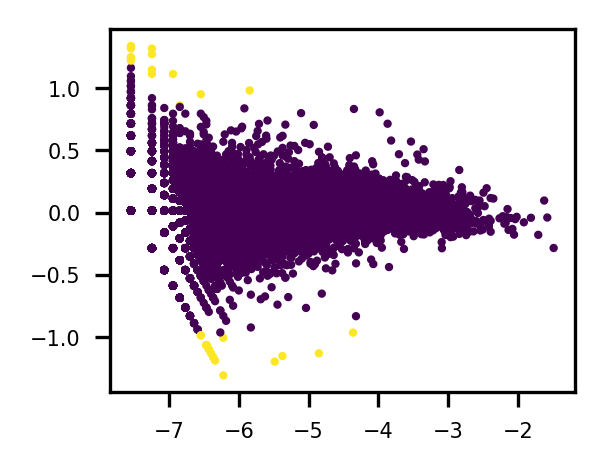

Exception: hey!

In [91]:
import itertools
import warnings
warnings.simplefilter(action='ignore', category=RuntimeWarning)



unique_zt = [0,6,12,18]
for cluster in clusters:
    print("DOING CLUSTER %s" % cluster)
    cluster_batch_effect_genes = []
    for description in descriptions:
        for zt in unique_zt:

            bool_1 = adata.obs['description'] == description
            bool_2 = adata.obs['cluster'] == cluster
            bool_3 = adata.obs['zt'] == zt
            sub_adata = adata[bool_1 & bool_2 & bool_3]
            unique_batches = sub_adata.obs['batch'].unique()


            for batch_1, batch_2 in itertools.combinations(unique_batches,2):
                print(batch_1,batch_2)

                # get the two batch adatas
                batch_sub_adata_1 = sub_adata[sub_adata.obs['batch'] == batch_1]
                batch_sub_adata_2 = sub_adata[sub_adata.obs['batch'] == batch_2]

                # get prop 1 and 2
                prop_1 = np.array(np.sum(batch_sub_adata_1.X,axis=0)).flatten() / np.sum(batch_sub_adata_1.obs['lib_size'])
                prop_2 = np.array(np.sum(batch_sub_adata_2.X,axis=0)).flatten() / np.sum(batch_sub_adata_2.obs['lib_size'])






                # get the effect df
                effect_df = pd.DataFrame()
                effect_df['effect'] = np.log10(prop_2) - np.log10(prop_1)
                effect_df['log10_prop_1'] = np.log10(prop_1)
                effect_df['log10_prop_2'] = np.log10(prop_2)
                effect_df['gene'] = adata.var_names
                effect_df = effect_df[np.array(prop_1 > 0) & np.array(prop_2 > 0)]
                effect_df = effect_df.set_index("gene")


                # subset the two batch adatas to the same genes as the effect
                batch_sub_adata_1 = batch_sub_adata_1[:,effect_df.index]
                batch_sub_adata_2 = batch_sub_adata_2[:,effect_df.index]



                # get the pearson residuals
                in_var = np.array(effect_df['log10_prop_1'])
                out_var = np.array(effect_df['effect'])
                pearson_residuals = compute_pearson_residuals(in_var,out_var,bw=0.01)
                effect_df['pearson_residual'] = pearson_residuals


                # get batch effect genes
                cluster_batch_effect_genes += list(effect_df[np.abs(effect_df['pearson_residual']) >= 5].index)
                print(len(cluster_batch_effect_genes))

                # viz
                fig,ax=plt.subplots(figsize=(2,1.6),dpi=300)
                plt.scatter(effect_df['log10_prop_1'], effect_df['effect'],s=1,c=np.abs(pearson_residuals) >= 5)
                plt.show()
                
                raise Exception("hey!")



    # ** write out list **
    fileout = '%s/cluster_%s.txt' % (folder_out,cluster)
    with open(fileout,'wb') as file_obj:
        file_obj.write("\n".join(cluster_batch_effect_genes).encode())

            
            

            
            
            

In [150]:
# --- GET BOOTSTRAPPED DISTRIBUTIONS ---


num_cells_to_subsample = 4000
num_shuffles = 1000
sampled_barcode_mat_1 = np.random.choice(batch_sub_adata_1.obs.index,size=(num_shuffles,num_cells_to_subsample),replace=True)
sampled_barcode_mat_2 = np.random.choice(batch_sub_adata_2.obs.index,size=(num_shuffles,num_cells_to_subsample),replace=True)



import tqdm
bootstrap_prop_1 = np.zeros((batch_sub_adata_1.shape[1],num_shuffles))
bootstrap_prop_2 = np.zeros((batch_sub_adata_1.shape[1],num_shuffles))
for shuffle in tqdm.tqdm(range(0,num_shuffles)):
    shuffle_adata_1 = batch_sub_adata_1[sampled_barcode_mat_1[shuffle,:]]
    shuffle_adata_2 = batch_sub_adata_2[sampled_barcode_mat_2[shuffle,:]]
    bootstrap_prop_1[:,shuffle] = np.array(np.sum(shuffle_adata_1.X,axis=0)).flatten() / np.sum(shuffle_adata_1.obs['lib_size'])
    bootstrap_prop_2[:,shuffle] = np.array(np.sum(shuffle_adata_2.X,axis=0)).flatten() / np.sum(shuffle_adata_2.obs['lib_size'])

bootstrap_log10_prop_1 = np.log10(bootstrap_prop_1)
bootstrap_log10_prop_2 = np.log10(bootstrap_prop_2)
interval_low = np.percentile(bootstrap_prop_1,0.5,axis=1)
interval_high = np.percentile(bootstrap_prop_1,99.5,axis=1)
fraction_outside_95_interval = np.mean((bootstrap_prop_2 < interval_low.reshape(-1,1)) | (bootstrap_prop_2 > interval_high.reshape(-1,1)),axis=1)






100%|███████████████████████████████████████| 1000/1000 [01:40<00:00,  9.95it/s]


In [136]:
(1 - 1e-3) * 100

99.9

In [190]:

# min_1 = np.min(bootstrap_prop_1,axis=1)
# max_1 = np.max(bootstrap_prop_1,axis=1)
# min_2 = np.min(bootstrap_prop_2,axis=1)
# max_2 = np.max(bootstrap_prop_2,axis=1)
thresh = 1e-4
min_1 = np.percentile(bootstrap_prop_1,thresh * 100,axis=1)
max_1 = np.percentile(bootstrap_prop_1,(1 - thresh) * 100.,axis=1)
min_2 = np.percentile(bootstrap_prop_2,thresh * 100,axis=1)
max_2 = np.percentile(bootstrap_prop_2,(1 - thresh) * 100.,axis=1)



is_greater = (min_2 > min_1) & (min_2 > max_1)
is_less = ((max_2 < min_1) & (max_2 < max_1))
is_in = ~(is_greater | is_less)
effect_df['is_greater'] = is_greater
effect_df['is_less'] = is_less
effect_df['is_in'] = is_in

effect_df.loc['Ccl5']


effect              1.271152
log10_prop_1       -7.241135
log10_prop_2       -5.969982
pearson_residual    6.350303
is_greater             False
is_less                False
is_in                   True
Name: Ccl5, dtype: object

In [195]:
effect_df[(effect_df['pearson_residual'] > 3) & (effect_df['is_in'])]




,effect,log10_prop_1,log10_prop_2,pearson_residual,is_greater,is_less,is_in
gene,,,,,,,
Il1rl1,1.162008,-7.542165,-6.380157,4.742642,False,False,True
1810006J02Rik,0.860978,-7.542165,-6.681187,3.159202,False,False,True
Lypd1,0.970122,-7.542165,-6.572042,3.733309,False,False,True
Plekha6,0.580151,-7.065043,-6.484892,3.023744,False,False,True
Ptprc,0.918970,-7.542165,-6.623195,3.464245,False,False,True
...,...,...,...,...,...,...,...
AC142100.1,0.860978,-7.542165,-6.681187,3.159202,False,False,True
Gm50375,0.828793,-7.241135,-6.412342,4.023458,False,False,True
Shtn1,0.714850,-7.241135,-6.526285,3.424109,False,False,True


In [181]:
gene_index = 10511
thresh
print(min_1[gene_index])
print(max_1[gene_index])
print(min_2[gene_index])
print(max_2[gene_index])




1.8246949817779524e-08
1.1077884494170576e-07
1.4979047602281526e-08
2.152447336811747e-06


In [168]:
np.where(effect_df.index == 'Ccl5')
# np.where(effect_df.index == 'Hba-a1')




(array([10511]),)

In [185]:
effect_df.loc['Hba-a1']

# effect_df.loc['Ccl5']

effect             -1.195927
log10_prop_1        -5.48526
log10_prop_2       -6.681187
pearson_residual   -6.254423
is_greater             False
is_less                 True
is_in                  False
Name: Hba-a1, dtype: object

In [167]:
np.sum(((max_2 < min_1) & (max_2 < max_1)))





0

In [102]:
bootstrap_log10_prop_1 = np.log10(bootstrap_prop_1) + np.mean(effect_df['effect'])
bootstrap_log10_prop_2 = np.log10(bootstrap_prop_2)
interval_low = np.percentile(bootstrap_prop_1,1e-3,axis=1)
interval_high = np.percentile(bootstrap_prop_1,1 - 1e-3,axis=1)
fraction_outside_95_interval = np.mean((bootstrap_prop_2 < interval_low.reshape(-1,1)) | (bootstrap_prop_2 > interval_high.reshape(-1,1)),axis=1)





(array([1.0000e+00, 3.0000e+00, 1.2000e+01, 2.2000e+01, 4.8000e+01,
        1.0000e+02, 2.2400e+02, 5.1400e+02, 1.1610e+03, 1.4404e+04]),
 array([0.22 , 0.298, 0.376, 0.454, 0.532, 0.61 , 0.688, 0.766, 0.844,
        0.922, 1.   ]),
 <BarContainer object of 10 artists>)

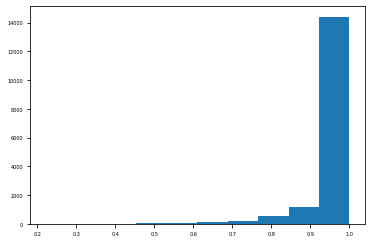

In [103]:
plt.hist(fraction_outside_95_interval)

In [ ]:

np.percentile(bootstrap_prop_1,0.5,axis=1)


In [156]:
np.where(effect_df.index == 'Ccl5')
# np.where(effect_df.index == 'Hba-a1')





(array([10511]),)

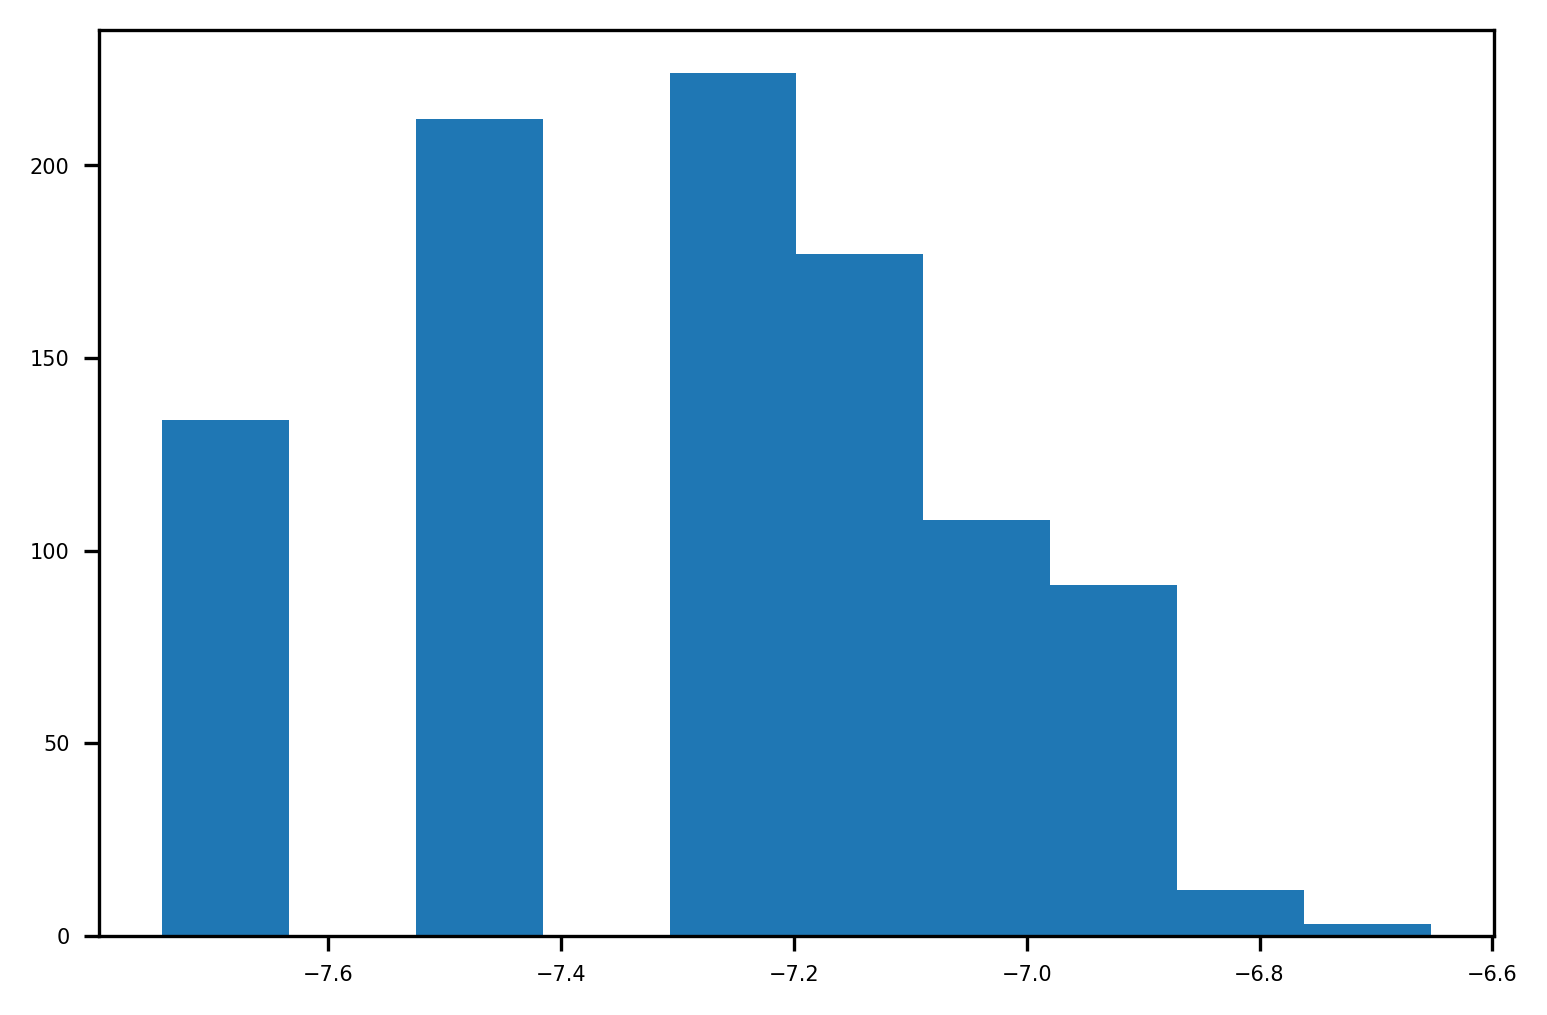

In [160]:

for gene_index in [10511]:
    fig,ax=plt.subplots(dpi=300)
    vals = bootstrap_prop_1[gene_index,:]
    vals = vals[vals > 0]
    plt.hist(np.log10(vals))
    plt.show()
    

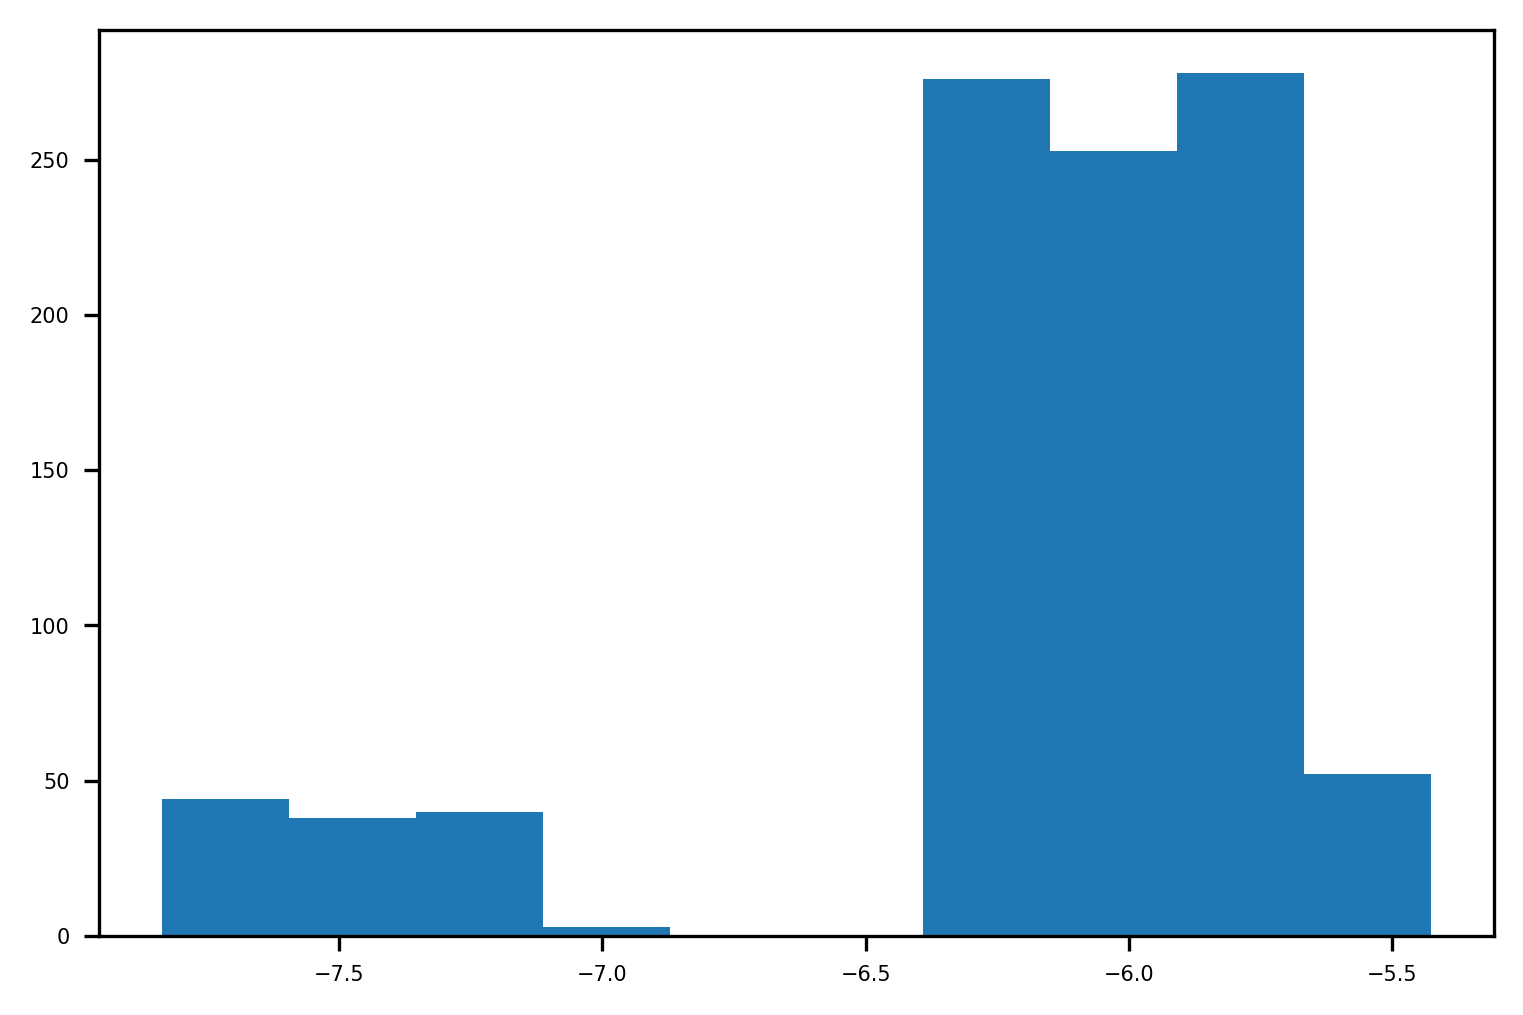

In [161]:
for gene_index in [10511]:
    fig,ax=plt.subplots(dpi=300)
    vals = bootstrap_prop_2[gene_index,:]
    vals = vals[vals > 0]
    plt.hist(np.log10(vals))
    plt.show()
    

(array([3706., 1158.,  741.,  520.,  507.,  475.,  473.,  456.,  624.,
        7829.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

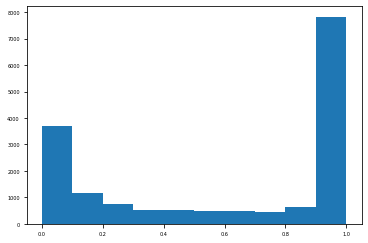

In [47]:
plt.hist(fraction_outside_95_interval)

In [42]:
fraction_outside_95_interval

array([0.85, 0.9 , 1.  , ..., 0.58, 1.  , 1.  ])

In [27]:
vals = np.mean(bootstrap_prop_2 - bootstrap_prop_1,axis=1)


# get the pearson residuals
in_var = np.log10(np.mean(bootstrap_prop_1,axis=1))
out_var = vals
pearson_residuals = compute_pearson_residuals(in_var,out_var,bw=0.01)
effect_df['pearson_residual2'] = pearson_residuals
effect_df['effect2'] = vals


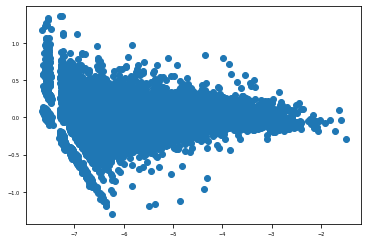

In [37]:
a = np.log10(np.mean(bootstrap_prop_1,axis=1))
b = np.log10(np.mean(bootstrap_prop_1,axis=1) + vals) - np.log10(np.mean(bootstrap_prop_1,axis=1))
plt.scatter(a,b)




In [36]:
np.log10(np.mean(bootstrap_prop_1,axis=1))

array([-6.02087663, -5.9283759 , -4.22962073, ..., -6.95637927,
       -5.02283214, -4.50642791])

In [34]:
effect_df['log10_prop_1']

,effect,log10_prop_1,log10_prop_2,pearson_residual,pearson_residual2,effect2
gene,,,,,,
Xkr4,0.204937,-6.023651,-5.818715,1.126051,0.011159,5.612812e-07
Gm19938,0.156059,-5.918916,-5.762857,0.859595,0.009883,5.546356e-07
Mrpl15,-0.118608,-4.229564,-4.348172,-0.693234,-0.407078,-1.420709e-05
Lypla1,-0.073277,-4.435974,-4.509252,-0.477684,-0.193748,-5.702150e-06
Tcea1,0.018181,-3.925060,-3.906878,-0.026299,-0.091530,5.143275e-06
...,...,...,...,...,...,...
CR974586.4,1.246329,-7.542165,-6.295836,5.186177,0.009866,4.616869e-07
4933409K07Rik,0.714850,-7.065043,-6.350194,3.732270,0.007652,3.600732e-07
Gm10931,-0.586180,-6.940105,-7.526285,-2.899872,-0.002279,-7.963655e-08


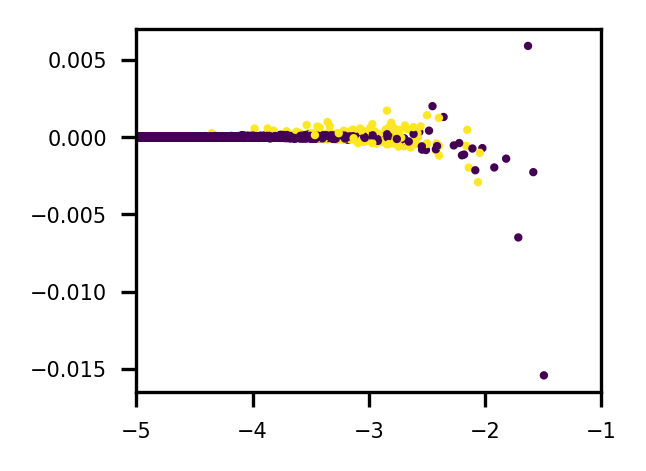

In [28]:
# viz
fig,ax=plt.subplots(figsize=(2,1.6),dpi=300)
plt.scatter(in_var, out_var,s=1,c=np.abs(pearson_residuals) >= 3)
plt.xlim((-5,-1))
plt.show()


In [352]:
effect_df.loc['Mcm6']

effect              0.377020
log10_prop_1       -4.817980
log10_prop_2       -4.440960
pearson_residual    1.762492
Name: Mcm6, dtype: float64

(array([   14.,    34.,    41.,    40.,    73.,   191.,   435.,  1264.,
         4034., 11877.]),
 array([-283.99881647, -255.66862656, -227.33843664, -199.00824673,
        -170.67805682, -142.3478669 , -114.01767699,  -85.68748708,
         -57.35729716,  -29.02710725,   -0.69691734]),
 <BarContainer object of 10 artists>)

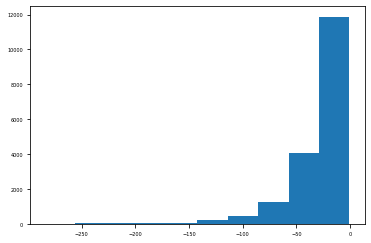

In [351]:
plt.hist(vals)

In [330]:
np.mean(bootstrap_prop_1,axis=1)

array([3.11969057e-06, 2.44317690e-06, 1.49729874e-07, ...,
       1.82089571e-08, 1.09085548e-05, 2.83199206e-05])

In [315]:

# get the pearson residuals
in_var = np.log10(np.mean(bootstrap_prop_1,axis=1))
out_var = np.log10(np.mean(bootstrap_prop_2,axis=1)) - np.log10(np.mean(bootstrap_prop_1,axis=1))
pearson_residuals = compute_pearson_residuals(in_var,out_var,bw=0.01)
effect_df['pearson_residual2'] = pearson_residuals





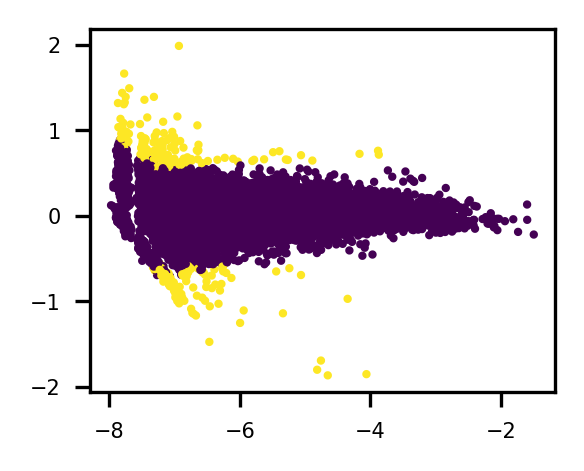

In [316]:
# viz
fig,ax=plt.subplots(figsize=(2,1.6),dpi=300)
plt.scatter(in_var, out_var,s=1,c=np.abs(pearson_residuals) >= 3)
plt.show()



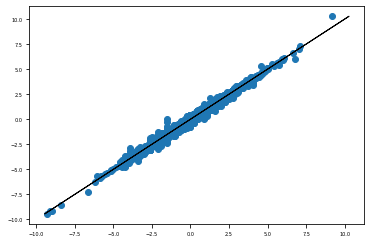

In [318]:
plt.scatter(effect_df['pearson_residual'],effect_df['pearson_residual2'])
plt.plot(effect_df['pearson_residual2'],effect_df['pearson_residual2'],c='k')

